In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qls
from molecules import CaOH, CaH, mu_N, gI
from scipy.constants import h, k
%matplotlib inline

### qls.States

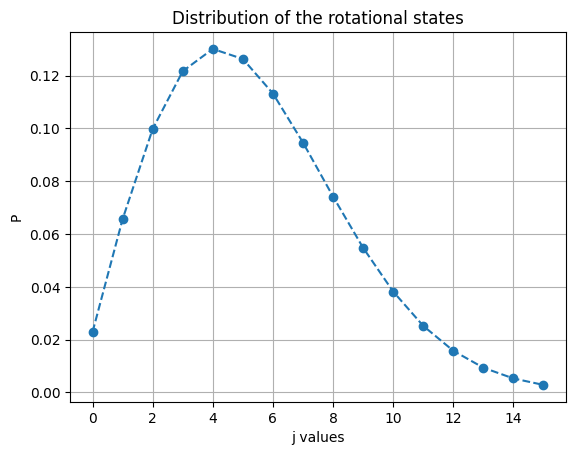

In [3]:
cah = CaH.from_file(b_field_gauss=6.5, j_max=15)
states = qls.States(cah, 300)
plt.plot(np.arange(cah.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()
plt.close()

In [4]:
# Check total probability

total_prob = np.sum(states.j_distribution())
print(total_prob)

0.9999999999999998


## Reproducing Chou et al. (2017)

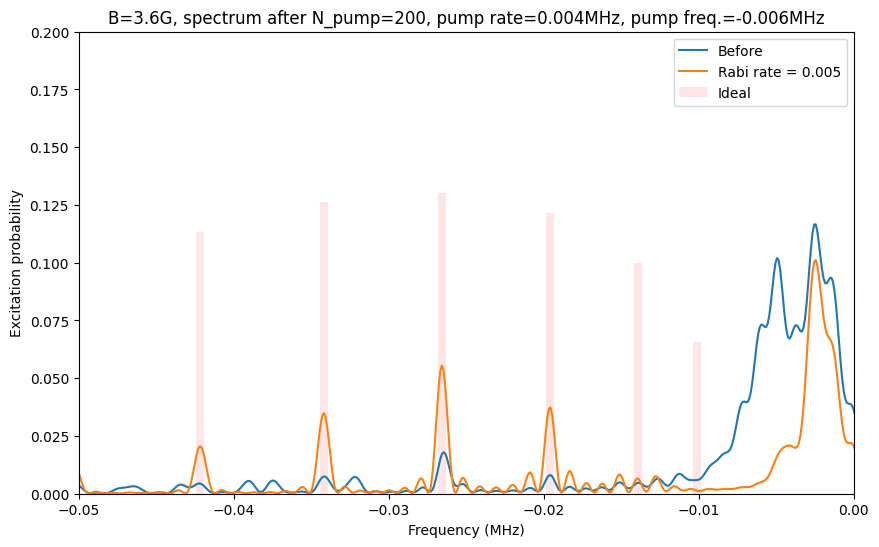

In [26]:
b_field_gauss = 3.6
j_max = 15

# I compute the molecule 
cah1 = CaH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)


temperature = 300
# I compute the states1. I do so because i need states1.dist,          J|m|csi|...|states1.dist
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .

states1 = qls.States(cah1, temperature)

# len(states1.dist) = len(cah1.states_df)

# I take the transition_df. For each j (multiplet), i take the energy difference of the target distribution.
signature_transitions = np.array([cah1.transition_df.loc[cah1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(cah1.j_max+1)])


# Then I apply the external Raman pulse. 
duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*0.005
max_frequency_mhz = 0.05
scan_points = 1000
dephased = False
is_minus = True

# get_spectrum: it takes excitation probability (from get_excitation_probabilities) + states1.dist distribution (from States) and np.dot @ freq.
# Then repeats for the frequencies and returns both the frequencies and the results @ each freq.
# This returns the spectrum before pumping.
frequencies, exc_probs1_before = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

# Then I pump the system n times to improve the population
pump_frequency_mhz = -0.006
num_pumps = 200
pump_dephased = True
pump_rabi_rate_mhz = 2*np.pi*0.004
pump_duration_us = 1000.0


# I update the state distribution (@ fixed j) with the exctiation matrix.
# I pump the system multiple times in order to better populate the molecule

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(cah1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, pump_dephased, is_minus).dot(states1.dist)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, exc_probs1_before, label = "Before")     # Plot before

frequencies, exc_probs1_after = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

ax.plot(frequencies, exc_probs1_after, label = f"Rabi rate = {rabi_rate_mhz/(2*np.pi):.3f}")      # Plot after
ax.bar(signature_transitions, states1.j_distribution(), color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.2])
plt.show()

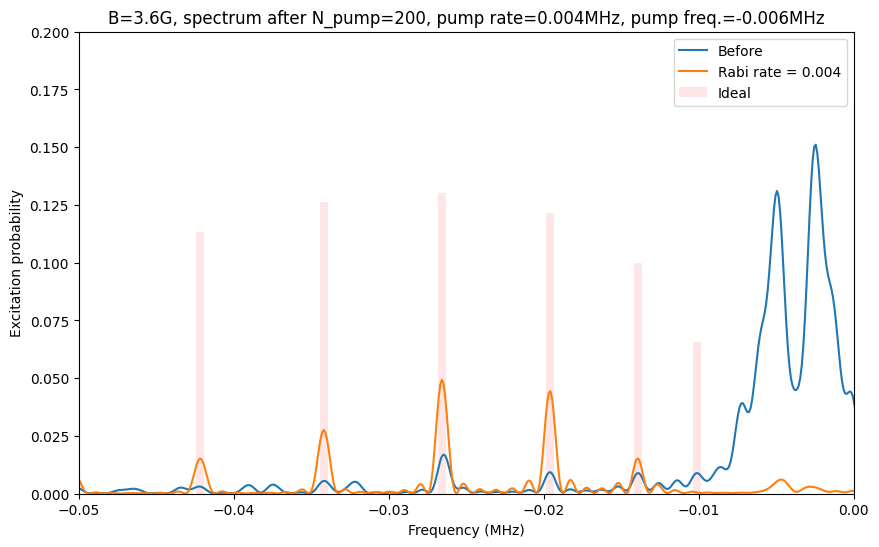

In [27]:
b_field_gauss = 3.6
j_max = 15

# I compute the molecule 
cah1 = CaH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)


temperature = 300
# I compute the states1. I do so because i need states1.dist,          J|m|csi|...|states1.dist
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .

states1 = qls.States(cah1, temperature)

# len(states1.dist) = len(cah1.states_df)

# I take the transition_df. For each j (multiplet), i take the energy difference of the target distribution.
signature_transitions = np.array([cah1.transition_df.loc[cah1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(1, cah1.j_max+1)])


# Then I apply the external Raman pulse. 
duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*0.004
max_frequency_mhz = 0.05
scan_points = 1000
dephased = False
is_minus = True

# get_spectrum: it takes excitation probability (from get_excitation_probabilities) + states1.dist distribution (from States) and np.dot @ freq.
# Then repeats for the frequencies and returns both the frequencies and the results @ each freq.
# This returns the spectrum before pumping.
frequencies, exc_probs1_before = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

# Then I pump the system n times to improve the population
pump_frequency_mhz = -0.002
num_pumps = 200
pump_dephased = True
pump_rabi_rate_mhz = 2*np.pi*0.004
pump_duration_us = 1000.0


# I update the state distribution (@ fixed j) with the exctiation matrix.
# I pump the system multiple times in order to better populate the molecule

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(cah1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, pump_dephased, is_minus).dot(states1.dist)


pump_frequency_mhz = -0.006

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(cah1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, pump_dephased, is_minus).dot(states1.dist)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, exc_probs1_before, label = "Before")     # Plot before

frequencies, exc_probs1_after = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

ax.plot(frequencies, exc_probs1_after, label = f"Rabi rate = {rabi_rate_mhz/(2*np.pi):.3f}")      # Plot after
ax.bar(signature_transitions, states1.j_distribution()[1:], color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.2])
plt.show()

# CaOH

## molecule info

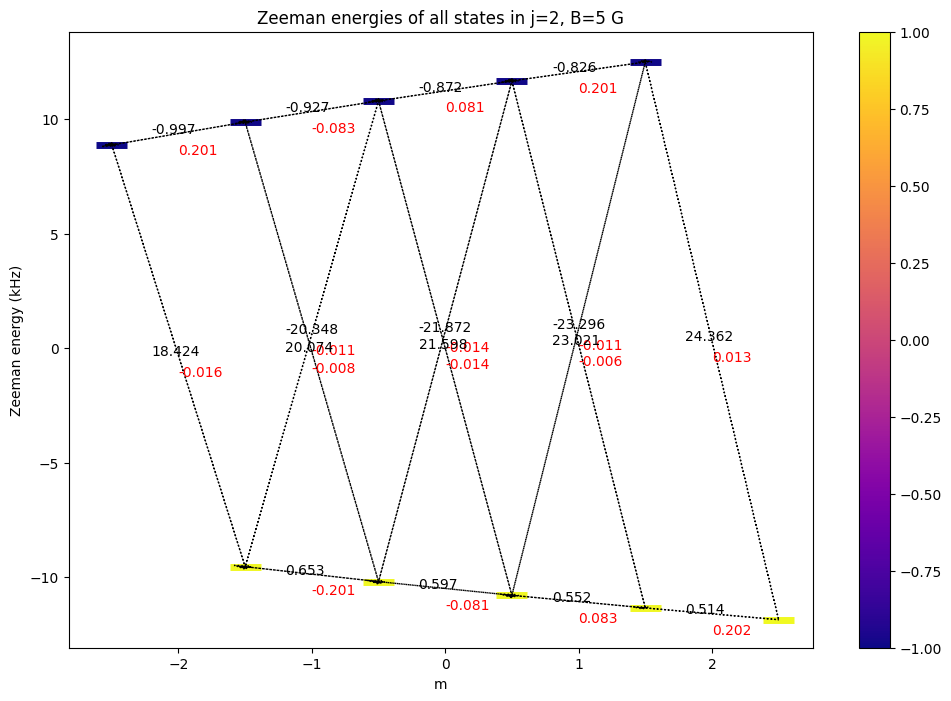

In [64]:
caoh = CaOH.from_file(b_field_gauss=5, j_max=50)

caoh.plot_zeeman_levels(2)

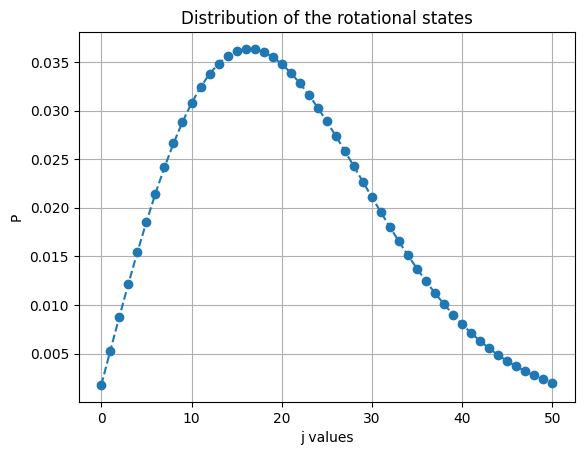

In [36]:
temperature = 300

states = qls.States(caoh, temperature)

# plt.bar(np.arange(caoh.j_max+1), states.j_distribution())
# plt.show()


plt.plot(np.arange(caoh.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()


### No pumping. Different B. Fixed Rabi Rate

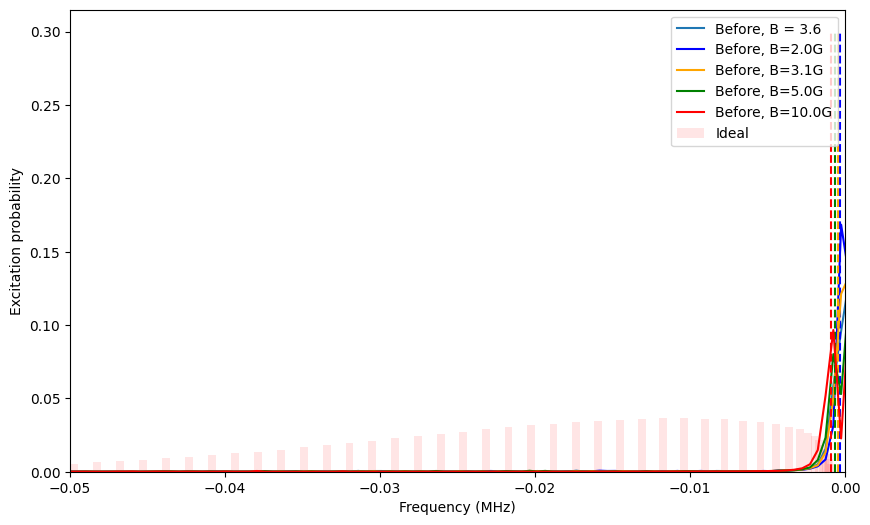

In [44]:
b_field_gauss = 3.6
j_max = 50


duration_us = 1500.0
rabi_rate_mhz = 2*np.pi*0.001
max_frequency_mhz = 0.05
scan_points = 200
dephased = True
is_minus = True


caoh = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states = qls.States(caoh, temperature)


signature_transitions = np.array([caoh.transition_df.loc[caoh.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(caoh.j_max+1)])

frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)


fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(frequencies, exc_probs, label = "Before, B = 3.6") 
ax.bar(signature_transitions, states.j_distribution(), color="red", width=0.0005, alpha=0.1, label = "Ideal")


b_fields_gauss = [2.0, 3.1, 5.0, 10.0]
colors = ["blue", "orange", "green", "red"]

# gj = caoh.gj
gj = -0.036

for b, color in zip(b_fields_gauss, colors):
    caoh = CaOH.from_file(b_field_gauss=b, j_max=50)
    states = qls.States(caoh, temperature)

    j_peak = np.argmax(states.j_distribution())
    peak_minus = - caoh.cb_khz * gj - ( caoh.cij_khz * caoh.cb_khz * (gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (gj - gI))**2 ) )
    peak_plus = - caoh.cb_khz * gj + ( caoh.cij_khz * caoh.cb_khz * (gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (gj - gI))**2 ) )

    frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs, color=color, label=f"Before, B={b}G")
    plt.vlines([-peak_minus * 1e-3, -peak_plus * 1e-3], 0, 0.3, color=color, linestyles="dashed")

plt.legend()
plt.xlabel("Frequency (MHz)")
plt.ylabel("Excitation probability")
plt.xlim([-max_frequency_mhz, 0])
# plt.yscale("log")
plt.show()

### Pumping.Fixed B = 2.0 Gauss and N_pump = 100; Different Rabi rates 

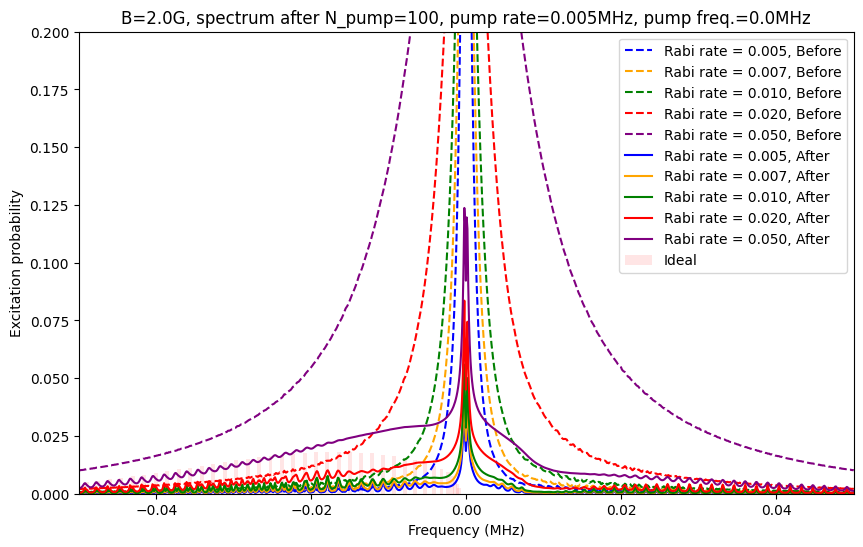

In [49]:
b_field_gauss = 2.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 100
pump_rabi_rate_mhz = 2*np.pi*0.005
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.legend()
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()

### Now B = 5.0 Gauss; and also pump_rabi_rate = 2 $\pi \cdot$ 0.02

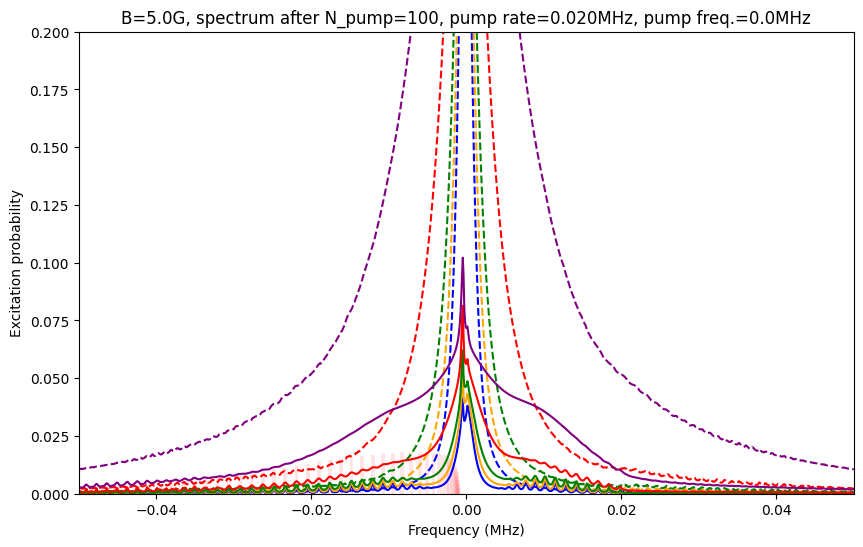

In [9]:
b_field_gauss = 5.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions_1 = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 100
pump_rabi_rate_mhz = 2*np.pi*0.02
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")


ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()


In [8]:
print(signature_transitions_1)
print(signature_transitions)

[ 0.02128874 -0.00093574 -0.0009972  -0.00106838 -0.00115163 -0.00125005
 -0.00136777 -0.00151041 -0.00168555 -0.00190349 -0.00217798 -0.00252664
 -0.00297037 -0.00353043 -0.00422303 -0.00505325 -0.00601292 -0.00708404
 -0.00824502 -0.00947559 -0.01075904 -0.01208254 -0.0134365  -0.01481386
 -0.01620942 -0.01761933 -0.01904067 -0.02047127 -0.02190941 -0.0233538
 -0.02480339 -0.02625737 -0.02771507 -0.02917595 -0.03063958 -0.03210558
 -0.03357365 -0.03504355 -0.03651505 -0.03798798 -0.03946217 -0.04093749
 -0.04241383 -0.04389108 -0.04536916 -0.04684799 -0.0483275  -0.04980763
 -0.05128832 -0.05276954 -0.05425124]
[ 0.02128874 -0.00093574 -0.0009972  -0.00106838 -0.00115163 -0.00125005
 -0.00136777 -0.00151041 -0.00168555 -0.00190349 -0.00217798 -0.00252664
 -0.00297037 -0.00353043 -0.00422303 -0.00505325 -0.00601292 -0.00708404
 -0.00824502 -0.00947559 -0.01075904 -0.01208254 -0.0134365  -0.01481386
 -0.01620942 -0.01761933 -0.01904067 -0.02047127 -0.02190941 -0.0233538
 -0.02480339 -0

### Now B = 2.0 Gauss; num_pump = 200; pump_rabi_rate = 2 $\pi \cdot$ 0.005

KeyboardInterrupt: 

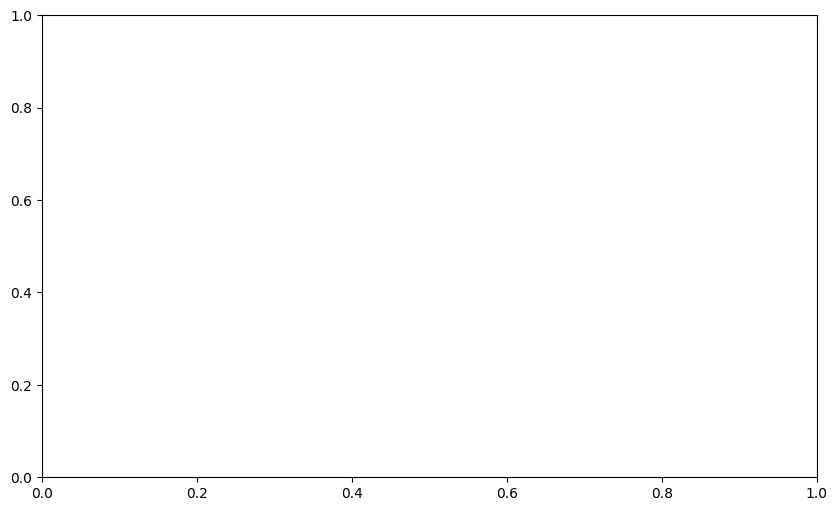

In [6]:
b_field_gauss = 2.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 200
pump_rabi_rate_mhz = 2*np.pi*0.02
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()

### Now B = 5.0 Gauss; num_pump = 200; pump_rabi_rate = 2 $\pi \cdot$ 0.02

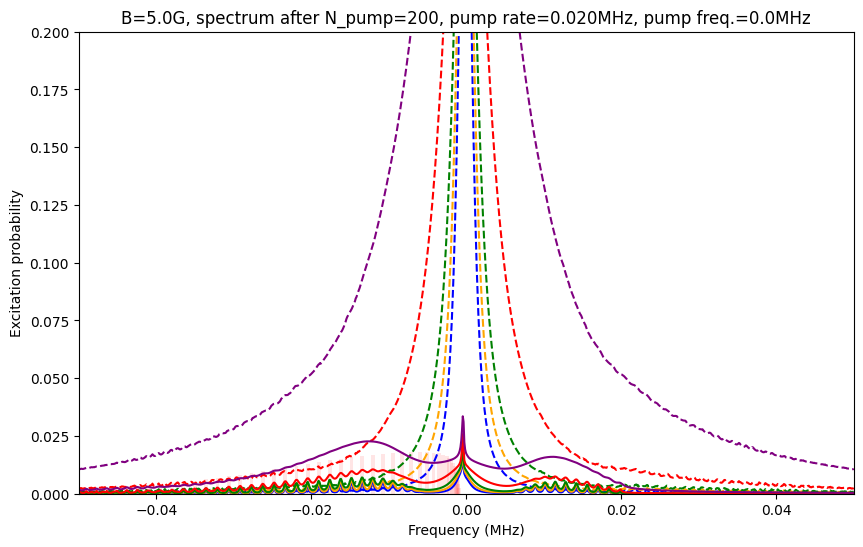

In [55]:
b_field_gauss = 5.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 200
pump_rabi_rate_mhz = 2*np.pi*0.02
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()

### Now B = 2.0 Gauss; num_pump = 1000; pump_rabi_rate = 2 $\pi \cdot$ 0.005

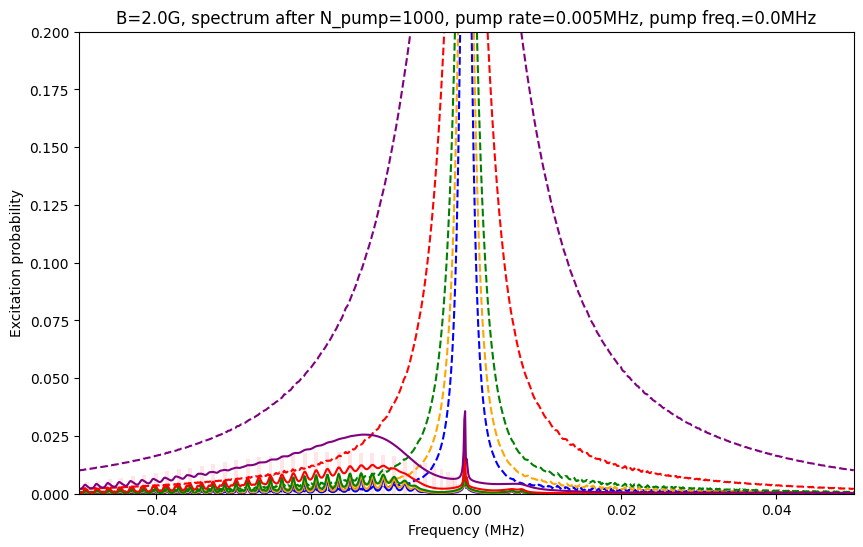

In [59]:
b_field_gauss = 2.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 1000
pump_rabi_rate_mhz = 2*np.pi*0.005
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()

### Now B = 5.0 Gauss; num_pump = 1000; pump_rabi_rate = 2 $\pi \cdot$ 0.005

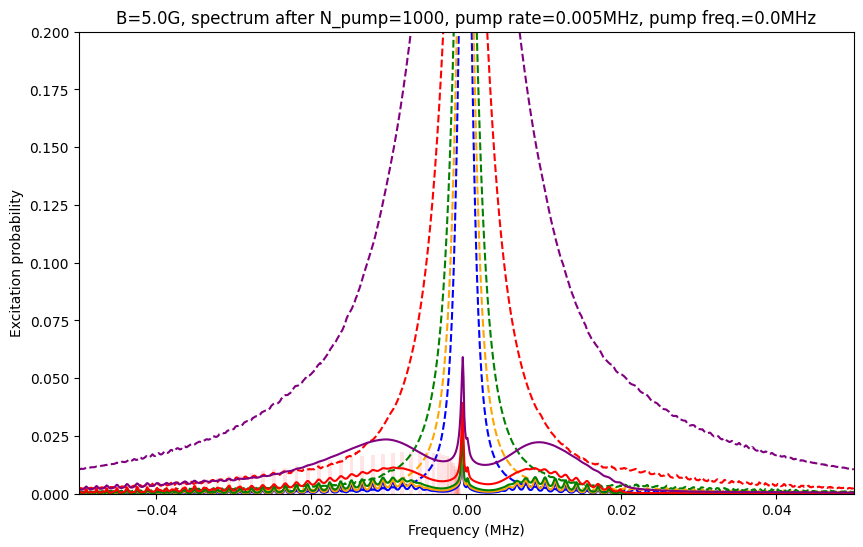

In [57]:
b_field_gauss = 5.0
j_max = 50

mo1 = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states1 = qls.States(mo1, temperature)


signature_transitions = np.array([mo1.transition_df.loc[mo1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(mo1.j_max+1)])


duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*np.array([0.005, 0.007, 0.01, 0.02, 0.05])
max_frequency_mhz = 0.05
scan_points = 1000
dephased = True
is_minus = True


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue", "orange", "green", "red", "purple"]

# Before
for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_before = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_before, linestyle = "--", color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, Before")


# After

pump_frequency_mhz = 0.000
num_pumps = 1000
pump_rabi_rate_mhz = 2*np.pi*0.005
pump_duration_us = 1000.0


for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(mo1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, dephased, is_minus).dot(states1.dist)


for i,r in enumerate(rabi_rate_mhz):
    frequencies, exc_probs1_after = qls.get_spectrum(mo1, states1.dist, duration_us, r, max_frequency_mhz, scan_points, dephased, is_minus)
    plt.plot(frequencies, exc_probs1_after, color=colors[i], label = f"Rabi rate = {r/(2*np.pi):.3f}, After")

ax.bar(signature_transitions, states1.j_distribution()*0.5, color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, max_frequency_mhz])
ax.set_ylim([0, 0.2])
plt.show()

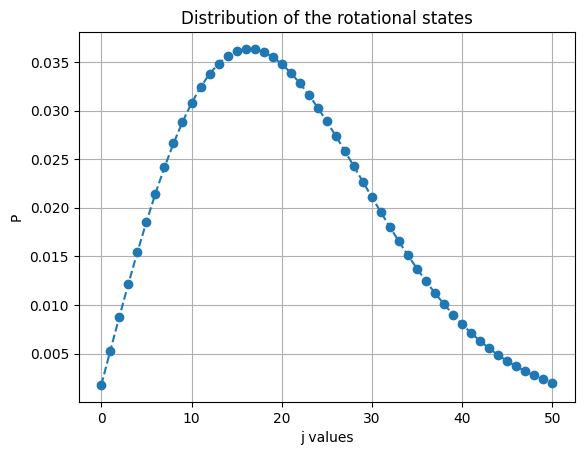

1.0000000000000004


In [13]:
mo1 = CaOH.from_file(b_field_gauss=0.0003, j_max=50)

# mo1.plot_zeeman_levels(4)
temperature = 300

states = qls.States(mo1, temperature)

# plt.bar(np.arange(caoh.j_max+1), states.j_distribution())
# plt.show()


plt.plot(np.arange(mo1.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()

print(sum(states.j_distribution()))


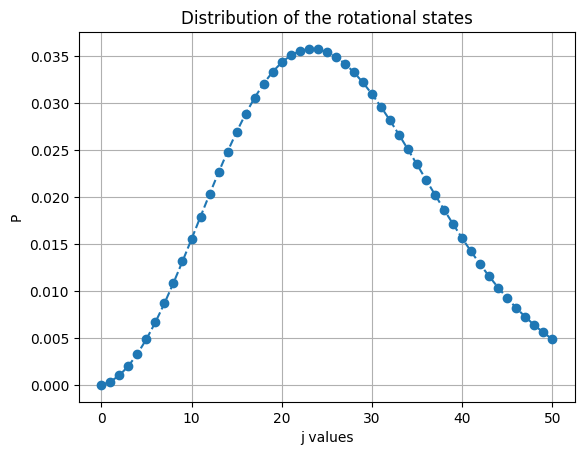

0.9999999999999997


In [3]:
mo1 = CaOH.from_file(b_field_gauss=0.0003, j_max=50)

# mo1.plot_zeeman_levels(4)
temperature = 300

states = qls.States(mo1, temperature)

# plt.bar(np.arange(caoh.j_max+1), states.j_distribution())
# plt.show()


plt.plot(np.arange(mo1.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()

print(sum(states.j_distribution()))
